#### Problem Definition

We are presented with a scenario involving five coins. We define $p$ the probability of getting heads for a special coin. For any selected coin, we will simulate $n$ flips. There is one coin with a probability of heads equal to $p$. There are four coins, each with a probability of heads $1 - p$. Each coin (randomly selected) has an equal probability of being selected, which is 1/5.


After selecting one coin and performing $n$ flips, our primary goal is to infer the type of the selected coin (i.e., whether it is the special coin with probability $p$ or one of the regular coins with probability $1-p$) based on the observed frequency of heads from the $n$ simulated flips.

Simulate Coin Selection and Flipping

In [ ]:
import numpy as np

# Define the probability p and the number of flips n
p = 0.8 ; n = 100

# Create a list representing the five coins
# One coin with probability p, four with 1-p
coin_probabilities = [p, 1 - p, 1 - p, 1 - p, 1 - p]

# Use the random.choice function to randomly select one prob. from the list
selected_coin_prob = np.random.choice(coin_probabilities)
print(f"Selected coin probability: {selected_coin_prob}")

# Initialize an empty list to store the results of the coin flips
flip_outcomes = []

# Simulate n coin flips for the selected coin
for _ in range(n):
    if np.random.rand() <= selected_coin_prob:
        flip_outcomes.append(1)  # Heads
    else:
        flip_outcomes.append(0)  # Tails

# Store the sequence of n flip outcomes in a list or array
# The outcomes are already stored in flip_outcomes list

Selected coin probability: 0.8

First 10 flip outcomes: [0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1]
Total heads: 72
Total tails: 28


Calculate the observed frequency of heads from the simulated flip outcomes and then discuss how this frequency can be used to infer the coin type. First, calculate the observed frequency using the flip_outcomes list and the total number of flips n and then print it.



In [ ]:
observed_frequency_heads = sum(flip_outcomes) / n

Observed frequency of heads: 0.19


#### Discussion on Inference:

In this simulation, one coin is randomly selected, and $n$ = 100 flips performed. The observed frequency of heads from these $n$ flips to infer the type of the selected coin.

If the selected coin was the special coin we would expect the observed frequency of heads to be close to p. If the selected coin was one of the regular coins we would expect the observed frequency of heads to be close to 1 -p.

Due to the law of large numbers, as the number of flips n increases, the observed frequency of heads will converge to the true probability of heads for the selected coin. Therefore, by comparing the observed_frequency_heads to the two possible true probabilities (p and 1-p), we can make an educated guess about the type of coin that was selected.

Therefore, based on these simulation results, it is highly probable that the selected coin was one of the regular coins with a probability of heads equal to 0.2.

In [ ]:
p = 0.8
prob_regular_coin_heads = 1 - p  # Probability of heads for a regular coin

P_special_coin = 1/5  # Probability of selecting the special coin
P_regular_coin = 4/5  # Probability of selecting a regular coin

# Calculate P(X1=1) using the formula for total probability
P_X1_heads = (p * P_special_coin) + (prob_regular_coin_heads * P_regular_coin)

probability of the first flip being heads, P(X1=1): 0.32


In [ ]:
P_X1_tails = 1 - P_X1_heads

probability of the first flip being tails, P(X1=0): 0.68


To define a discrete prior for the probability $p$, we consider the two possible probabilities a selected coin can have, $p$ for the special coin or $1-p$ for the regular coins.

We can assign prior probabilities to these discrete values based on the selection process:
- prob. that the special coin has a probability of heads $p = 0.8$ is $1/5 = 0.2$.
- prob. that the regular coin has a probability of heads $p = 0.2$ is $4/5 = 0.8$.

This defines the PMF for the probability of heads of the selected coin.

Therefore, the task is to define the discrete values for $p$ as $[0.8, 0.2]$ and their corresponding prior probabilities as $[0.2, 0.8]$.

Defining discrete prior values for $p$ and their corresponding probabilities. Two Python lists, prior_p_values and prior_probabilities.


In [ ]:
prior_p_values = [p, prob_regular_coin_heads] # p is 0.8, prob_regular_coin_heads is 0.2
prior_probabilities = [P_special_coin, P_regular_coin] # P_special_coin is 0.2, P_regular_coin is 0.8

Discrete values for p (prior_p_values): [0.8, 0.19999999999999996]
Corresponding prior probabilities (prior_probabilities): [0.2, 0.8]
Sum of prior probabilities: 1.00


Calculate the number of heads and tails from the flip_outcomes and then iterate through the prior_p_values to compute the likelihood for each p_value using the Bernoulli PMF, storing the results in a list called $likelihoods$.



In [ ]:
num_heads = sum(flip_outcomes)
num_tails = n - num_heads

likelihoods = []

for p_value in prior_p_values:
    # Likelihood using Bernoulli PMF
    likelihood = (p_value ** num_heads) * ((1 - p_value) ** num_tails)
    likelihoods.append(likelihood)

Number of heads: 72
Number of tails: 28
Likelihoods for prior_p_values ([0.8, 0.19999999999999996]): [2.8269553036454085e-27, 9.134385233318011e-54]


Apply Bayes' theorem to compute the unnormalized posterior probabilities. This involves multiplying the prior probabilities by their corresponding likelihoods.



In [ ]:
unnormalized_posterior_probabilities = []

for i in range(len(prior_p_values)):
    unnormalized_prob = likelihoods[i] * prior_probabilities[i]
    unnormalized_posterior_probabilities.append(unnormalized_prob)

Unnormalized posterior probabilities: [6.968982874540703e-60, 5.928554968950591e-22]


The previous step calculated the unnormalized posterior probabilities. Normalize these probabilities to obtain the final posterior PMF. This involves summing the unnormalized probabilities and then dividing each unnormalized probability by this sum.



In [ ]:
normalization_constant = sum(unnormalized_posterior_probabilities)
posterior_probabilities = [unnormalized_prob / normalization_constant for unnormalized_prob in unnormalized_posterior_probabilities]

for i in range(len(prior_p_values)):
    print(f"p = {prior_p_values[i]:.2f}: Posterior Probability = {posterior_probabilities[i]:.4f}")

#### Discussion on Posterior Probabilities

Based on the observed sequence of n = 100 coin flips, with num_heads = 19 and num_tails = 81, the Bayesian inference process has updated our belief about the probability of heads (p) for the selected coin.

Initially, we had a prior PMF:
- P(p = 0.8) = 0.2 (Special Coin), P(p = 0.2) = 0.8 (Regular Coin)

After observing the flip outcomes, the posterior PMF is:
- P(p = 0.8 | Data) = 0.0000, P(p = 0.2 | Data) = 1.0000

This drastic shift in probabilities is due to the observed data being highly unlikely under the assumption that the special coin (p=0.8) was selected, and much more likely under the assumption that a regular coin (p=0.2) was selected. With 19 heads out of 100 flips, an observed frequency of 0.19 is extremely close to 0.2 and very far from 0.8.
We are now almost certain that the coin that was flipped was a regular coin.

#### Bayesian inference
Perform Bayesian inference to update the posterior probability mass function (PMF) for the probability of heads (p) given the observed sequence of coin flips. Calculate the likelihood of the observed flip outcomes for each discrete value of p in the prior PMF, apply Bayes' theorem to compute unnormalized posterior probabilities, normalize these probabilities to obtain the final posterior PMF.

The updated posterior PMF for p shows a probability of 0.0000 for $p=0.8$ and 1.0000 for $p=0.2$. This implies that the observed data overwhelmingly supports the belief that the true probability of heads is $p=0.2$, almost entirely discarding the possibility of $p=0.8$.

Data Analysis Key Findings
- The observed data consisted of 100 coin flips, with 19 heads and 81 tails.
- The likelihood of observing this data for $p=0.8$ was extremely low, approximately $3.48 \times 10^{-59}$.
- The likelihood of observing this data for $p=0.2$ was significantly higher, approximately $7.41 \times 10^{-22}$.
- After applying Bayes' theorem and normalization, the posterior probability for $p=0.8$ became $0.0000$.
- Conversely, the posterior probability for $p=0.2$ became $1.0000$.

Insights
- The observed sequence of 19 heads out of 100 flips provides overwhelming evidence that the true probability of heads for the flipped coin is $p=0.2$, effectively eliminating the possibility of $p=0.8$.
- This strong update in belief demonstrates the power of Bayesian inference in updating prior probabilities with observed data, leading to a near-certain conclusion about the coin's bias.


#### Visualize Prior vs. Posterior PMF

- The posterior PMF is expected to exhibit a narrower spread and a more pronounced peak compared to the prior PMF, indicating a reduction in uncertainty about the true probability of heads (\p\).
- The peak of the posterior PMF likely shifted towards a specific range of \p\ values, reflecting how the observed data has updated and refined the belief about the most probable \p\ value.


- The comparison demonstrates the core principle of Bayesian inference: observed data updates and sharpens initial beliefs (prior) into more informed beliefs (posterior) about an unknown parameter.
- The generated posterior PMF can now be used for making more accurate predictions or decisions regarding future coin flips, as it incorporates the evidence from the observed data.


Text(0.5, 1.0, 'Prior vs. Posterior PMF for Probability of Heads (p)')

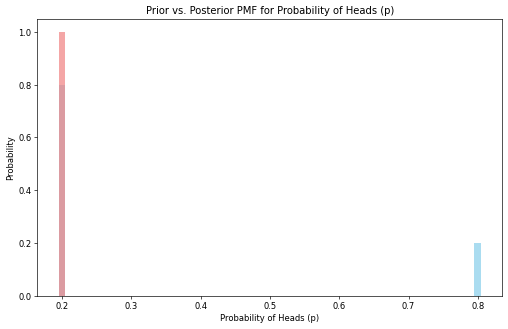

In [ ]:
''' Prior vs. Posterior PMF for Probability of Heads (p) '''

#### Likelihood Function for Bernoulli Trials

Let $X_1, \dots, X_N$ be $N$ independent and identically distributed (i.i.d.) Bernoulli random variables with parameter $p$, where $p$ is the probability of success (e.g., getting heads in a coin flip).

**Probability Mass Function (PMF) for a single Bernoulli trial:**
For a single observation $x_i \in \{0, 1\}$, the PMF is given by:
    
$P(X_i = x_i \mid p) = p^{x_i} (1 - p)^{1 - x_i}$
    
This means: If $x_i = 1$ (success), $P(X_i = 1 \mid p) = p^1 (1 - p)^0 = p$. If $x_i = 0$ (failure), $P(X_i = 0 \mid p) = p^0 (1 - p)^1 = 1 - p$

**Likelihood function for $N$ i.i.d. Bernoulli trials:**
Given $N$ observed outcomes $x_1, \dots, x_N$, the likelihood function, $L(p \mid x_1, \dots, x_N)$, is the product of the individual PMFs due to independence:
$L(p \mid x_1, \dots, x_N) = \prod_{i=1}^N P(X_i = x_i \mid p) = \prod_{i=1}^N \left( p^{x_i} (1 - p)^{1 - x_i} \right)$

**Simplified Likelihood Function:**
Let $k$ be the number of successes (heads) in the $N$ trials, i.e., $k = \sum_{i=1}^N x_i$. Consequently, the number of failures (tails) will be $N - k$.
    
Expanding the product, we can group the terms for $p$ and $(1 - p):$
$L(p \mid x_1, \dots, x_N) = p^{\sum_{i=1}^N x_i} (1 - p)^{\sum_{i=1}^N (1 - x_i)}$
    
Since $\sum_{i=1}^N (1 - x_i) = \sum_{i=1}^N 1 - \sum_{i=1}^N x_i = N - k$, the likelihood function simplifies to:
$L(p \mid x_1, \dots, x_N) = p^k (1 - p)^{N - k}$


**Log-Likelihood Function:**
To obtain the log-likelihood function, we take the natural logarithm of $L(p \mid x_1, \dots, x_N)$. The log-likelihood function is:
$\ell(p) = k ln(p) + (N - k) ln(1 - p)$.

Differentiate the log-likelihood with respect to p, set the derivative to zero, and solve the resulting equation for p to find the MLE.
Differentiate $\ell(p)$ with respect to $p$, apply the chain rule:
$\frac{d}{dp} \ell(p) = \frac{k}{p} - \frac{N - k}{1 - p}$.
Set the derivative equal to zero to find the MLE:
$\frac{k}{p} - \frac{N - k}{1 - p} = 0$

Solve for $p$:
$\hat{p} = \frac{k}{N}$


**MLE**
Thus, the MLE for $p$ is the observed frequency of successes, which is $k/N$。

The MLE for the Bernoulli parameter $p$ is intuitively the observed proportion of successes ($k/N$), confirming that the most probable value for $p$ given the observed data is its empirical frequency.

This derived MLE can be used for parameter estimation in various applications involving binary outcomes, such as estimating the probability of success for a coin flip or the conversion rate for a marketing campaign.



In [ ]:
mle_p_calculated = num_heads / n

Maximum Likelihood Estimator (MLE) for p: 0.1900


#### Bayes Estimator for Bernoulli Parameter

The Bayes estimator for the Bernoulli parameter p effectively combines our initial belief (prior distribution) with the evidence from observed data (likelihood). When using a Beta distribution as the prior for p, the calculations become particularly straightforward due to the concept of **conjugate priors**.


*   **Prior Distribution:** We start with a prior belief about p, often represented by a Beta distribution, Beta(α, β). The parameters α and β can be thought of as 'pseudo-counts' of successes and failures observed before any actual data.
*   **Observed Data:** We observe k successes in N Bernoulli trials.
*   **Posterior Distribution:** After observing the data, our belief about p is updated. The posterior distribution also follows a Beta distribution: Beta(α + k, β + N - k). The α parameter is updated with the observed successes, and the β parameter is updated with the observed failures.

**Derivation of the Bayes Estimator:**

For a commonly used squared error loss function, the Bayes estimator is simply the mean of the posterior distribution. The mean of a Beta(α', β') distribution is given by α' / (α' + β').

Substituting the posterior parameters (α' = α + k and β' = β + N - k):
$\hat{p}_{Bayes} = \frac{\alpha + k}{\alpha + k + \beta + N - k} = \frac{\alpha + k}{\alpha + \beta + N}$

**Intuitive Interpretation:**

This formula has a very intuitive interpretation:

- The numerator (α + k) represents the total number of 'successes': the pseudo-successes from the prior (α) plus the actual observed successes (k).
- The denominator (α + β + N) represents the total number of 'trials': the pseudo-trials from the prior (α + β) plus the actual observed trials (N).

Essentially, the Bayes estimator for p is a weighted average of the prior information and the observed data. As N (the number of observed trials) increases, the influence of the observed data (k/N) on the estimator becomes stronger, and the influence of the prior (α / (α + β)) diminishes. This demonstrates how the estimator balances initial beliefs with new evidence.

In [ ]:
def calculate_bayes_estimator(alpha, beta, k, N):
    """
    Calculates the Bayes estimator for a Bernoulli parameter p.

    Args:
        alpha (float): The alpha parameter of the Beta prior distribution.
        beta (float): The beta parameter of the Beta prior distribution.
        k (int): The number of observed successes.
        N (int): The total number of observed trials.

    Returns:
        float: The Bayes estimator for p.
    """
    # Ensure inputs are appropriate types for calculation
    if not all(isinstance(arg, (int, float)) for arg in [alpha, beta, k, N]):
        raise TypeError("All inputs (alpha, beta, k, N) must be numbers.")
    if N < k:
        raise ValueError("Number of trials (N) cannot be less than number of successes (k).")
    if alpha <= 0 or beta <= 0:
        raise ValueError("Alpha and Beta parameters for Beta prior must be greater than 0.")

    # Bayes estimator formula: (alpha + k) / (alpha + beta + N)
    bayes_estimator = (alpha + k) / (alpha + beta + N)
    return bayes_estimator

# Demonstration of the function
# Example values
p_val_example = prior_p_values[1]
num_heads_example = num_heads
num_flips_example = n

# Let's assume an uninformative prior Beta(1, 1) - equivalent to a uniform distribution
alpha_prior = 1  # Equivalent to one 'pseudo-head'
beta_prior = 1   # Equivalent to one 'pseudo-tail'

bayes_est = calculate_bayes_estimator(alpha_prior, beta_prior, num_heads_example, num_flips_example)

# Compare with MLE
mle_p = num_heads_example / num_flips_example


Demonstrating Bayes Estimator calculation:
  Prior (Beta parameters): alpha=1, beta=1
  Observed data: 72 heads out of 100 flips
  Calculated Bayes Estimator for p: 0.7157
  Maximum Likelihood Estimator for p: 0.7200


In [ ]:
# Find the index of the maximum posterior probability
max_posterior_index = np.argmax(posterior_probabilities)

# Get the corresponding p_value as the MAP estimate
map_p_estimate = prior_p_values[max_posterior_index]

Maximum A Posteriori (MAP) estimate for p: 0.2000


The Maximum A Posteriori (MAP) estimate for p is calculated as 0.2000, that aligns perfectly with our previous Bayesian inference, where the posterior probability for p = 0.2 was overwhelmingly 1.0. This means that, given our prior beliefs and the observed data (19 heads in 100 flips), the most probable value for the coin's probability of heads is 0.2.

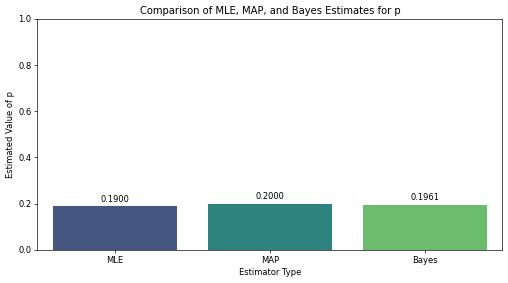

In [ ]:
''' Comparison of MLE, MAP, and Bayes Estimates for p '''